# Hierarchical Demand Forecasting on M5 Walmart Dataset
## Predicting Item-Level Sales Using Aggregate Disaggregation

**Dataset:** M5 Forecasting Competition (Walmart sales, 3,049 items × 10 stores)  
**Approach:** Two-level hierarchical forecasting with XGBoost  
**Result:** 21% improvement over seasonal naive baseline (RMSE)

### Project Overview
This notebook implements a hierarchical forecasting approach to predict daily 
item-level sales for Walmart stores. Rather than forecasting 30,490 individual 
time series directly, we forecast at the aggregate department+store level 
(70 series) then disaggregate to item level using predicted sales proportions.

In [1]:
##Importing necessary Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
##Loading all the datasets
Data_Dir = "/Users/satyaraotummalla/Documents/M5"
sales_train = pd.read_csv(f"{Data_Dir}/sales_train_validation.csv") 
Calendar = pd.read_csv(f"{Data_Dir}/calendar.csv")
sales_validation = pd.read_csv(f"{Data_Dir}/sales_train_evaluation.csv")
selling_prices = pd.read_csv(f"{Data_Dir}/sell_prices.csv")

## Objective
Forecast the next **28 days of sales** using 6 years of historical sales, 
weekly store-level prices, and calendar events.

We begin with some **EDA and visualization** to understand the data before modelling.

In [3]:
sales_train.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


In [4]:
## Skimming through the Sales_train
{col:sales_train[col].nunique() for col in sales_train.iloc[:,1:6].columns}

{'item_id': 3049, 'dept_id': 7, 'cat_id': 3, 'store_id': 10, 'state_id': 3}

### Why 70 Time Series?

A core principle in demand forecasting is that **aggregate level forecasts are more 
accurate than granular ones** — whether aggregated by time, location, or category.

Forecasting at the **dept+store level** allows us to capture meaningful demand patterns 
for each department within each store, without the noise that comes with item-level data.

| Level | Count |
|---|---|
| Unique Items | 3,049 |
| Departments | 7 |
| Stores | 10 |
| **Our Time Series** | **70 (7 × 10)** |

Moving from 3,049 item-level series down to just **70 time series** is also a 
significant computational win — making modelling faster and more stable without 
sacrificing much forecasting accuracy.

In [5]:
#Quick Look at Selling Prices
selling_prices.head(3)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26


In [6]:
## Converting the sales dataset into desired format
viz_train = sales_train.melt(
    id_vars=sales_train.columns[0:6],
    var_name="d",
    value_name="sales"
)
##Getting Item Level Prices into Sales dataset
viz_train = viz_train.merge(Calendar[["wm_yr_wk","d"]], on = 'd', how = "left" )
viz_train = viz_train.merge(selling_prices, on = ["store_id","item_id","wm_yr_wk"], how = "left")

In [7]:
viz_train.isna().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
wm_yr_wk             0
sell_price    12299413
dtype: int64

There are **12.2 million missing values** in `sell_price` — this isn't random noise. 
Missing prices usually mean the item wasn't available at that store yet, or the price 
simply wasn't logged that week.

Getting this right matters — a corrupted price signal would quietly poison everything 
downstream, especially since price is central to our disaggregation model later.

Let's pick an item+store combination and see what's going on.

In [8]:
# Filter dataset for a specific store-item combination
item_store = viz_train.loc[
    (viz_train['store_id'] == 'CA_1') & 
    (viz_train['item_id'] == 'HOBBIES_1_001')
]

# Get positions (row indices, column indices) of all NaN values
nan_pos = np.where(item_store.isna())

# Extract the row indices of NaNs → nan_pos[0]
# Take the LAST occurrence of a NaN row
last_nan_row = nan_pos[0][-1]

# Select all rows from the last NaN row till the end
item_store.iloc[last_nan_row:,]

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wm_yr_wk,sell_price
27288550,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_896,0,11324,NaN
27319040,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_897,0,11325,9.58
27349530,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_898,0,11325,9.58
27380020,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_899,0,11325,9.58
27410510,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_900,0,11325,9.58
...,...,...,...,...,...,...,...,...,...,...
58174920,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1909,1,11612,8.38
58205410,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1910,3,11612,8.38
58235900,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1911,0,11612,8.38
58266390,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1912,1,11613,8.38


## Data Cleaning — Sell Price & Pre-Launch Zeros

One thing that stood out during EDA was that some items had long stretches of zero sales and missing prices right at the start of their history. 
Take `HOBBIES_1_001` in store `CA_1` — no sales, no price, for the first 896 days. The product simply wasn't on the shelves yet.

This matters more than it seems. If we filled those missing prices with the mean and kept those rows, we'd essentially be telling the model:

> *"Hey, at $6.73 this product sold zero units for 896 straight days"*

But that's not a pricing story — that's a launch story. The model doesn't know the difference,
so it's on us to make sure we're not feeding it the wrong signal. A corrupted price-demand relationship at this stage would 
quietly poison everything downstream, especially since price is central to our disaggregation model.

**So here's what we do:**
- Any rows before an item's first recorded sale are dropped entirely
- If a price goes missing *after* launch, we forward fill it — because in retail, no price update usually just means the price didn't change 
  that day and wasn't logged due to human error

Simple logic, but getting this right is the difference between a model that learns real demand behaviour and one that learns noise.

In [9]:
##Defining a function that does the above for us
def clean_item_prices(df):
    df = df.sort_values(['item_id', 'store_id', 'd'])

    # First sale day per item-store
    first_sale = df.loc[df['sales'] > 0].groupby(
        ['item_id', 'store_id']
    )['d'].min()

    # Map instead of merge
    key = list(zip(df['item_id'], df['store_id']))
    df['first_sale_d'] = pd.Series(key).map(first_sale)

    # Filter early
    df = df[df['d'] >= df['first_sale_d']]

    # Fast forward fill
    df['sell_price'] = df.groupby(
        ['item_id', 'store_id']
    )['sell_price'].ffill()

    return df.drop(columns='first_sale_d')

## Calling the function
viz_train = clean_item_prices(viz_train)

cols = ["dept_id", "store_id", "d"]

for col in cols:
    viz_train[col] = viz_train[col].astype("category")

In [10]:
##Converting training dataset into the aggregation that is useful for us (essentially 70 time series)
df_train = (
    viz_train
    .drop(columns=["id", "item_id", "cat_id", "state_id", "wm_yr_wk"])
    .groupby(["dept_id", "store_id", "d"], observed=True)
    .agg({"sales": "sum"})
    .reset_index()
)

df_train['d_num'] = df_train['d'].str.extract(r'(\d+)').astype(int)

df_train.sort_values(by=["dept_id", "store_id", "d_num"], inplace=True)

df_train.reset_index(drop=True, inplace= True)
df_train.head()

,dept_id,store_id,d,sales,d_num
0,FOODS_1,CA_1,d_1,297,1
1,FOODS_1,CA_1,d_2,284,2
2,FOODS_1,CA_1,d_3,214,3
3,FOODS_1,CA_1,d_4,175,4
4,FOODS_1,CA_1,d_5,182,5


---
### 🗓️ Now we have our Core 70 Time Series
#### These will form the basis of our Aggregate Level Forecasts
---

## Feature Engineering

Before building the forecasting model, we engineer features that capture the key 
drivers of retail sales — time patterns, pricing, and external events.

We begin by exploring the **Calendar** dataset, which contains information about 
dates, days of the week, months, and special events — all of which are expected 
to influence sales patterns.

In [11]:
Calendar.head(3)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


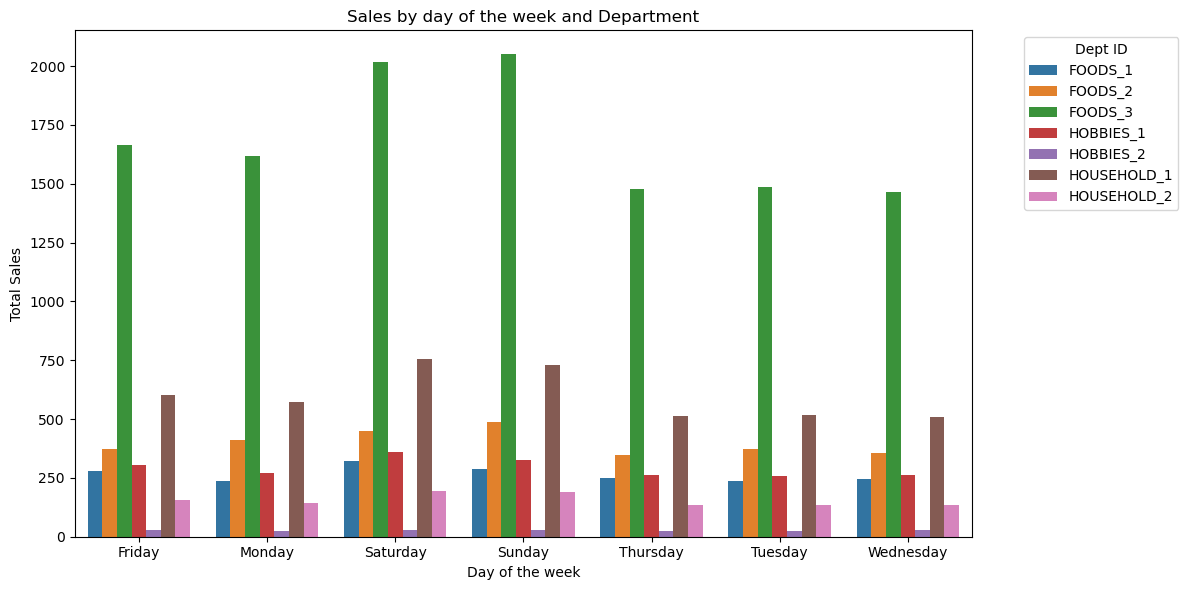

In [12]:
## Let's explore important features that we can use for our model from Calendar Table
merged_df = pd.merge(df_train,Calendar,on="d", how = "left") 

merged_df['weekday'] = merged_df['weekday'].fillna('No-Event') ### Adding Non_Event days to see the real Impact

X = (
    merged_df
    .groupby(["weekday", "dept_id"], observed=True)["sales"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(12, 6))
sns.barplot(data=X, x="weekday", y="sales", hue="dept_id")
plt.title("Sales by day of the week and Department", fontsize=12)
plt.xlabel("Day of the week")
plt.ylabel("Total Sales")
plt.legend(title="Dept ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Weekends **(Saturday & Sunday)** show a consistently higher sales pattern compared 
to weekdays — this is a clear and reliable signal worth capturing.

We'll add an `is_weekend` binary feature to explicitly tell the model that 
these two days behave differently from the rest of the week.

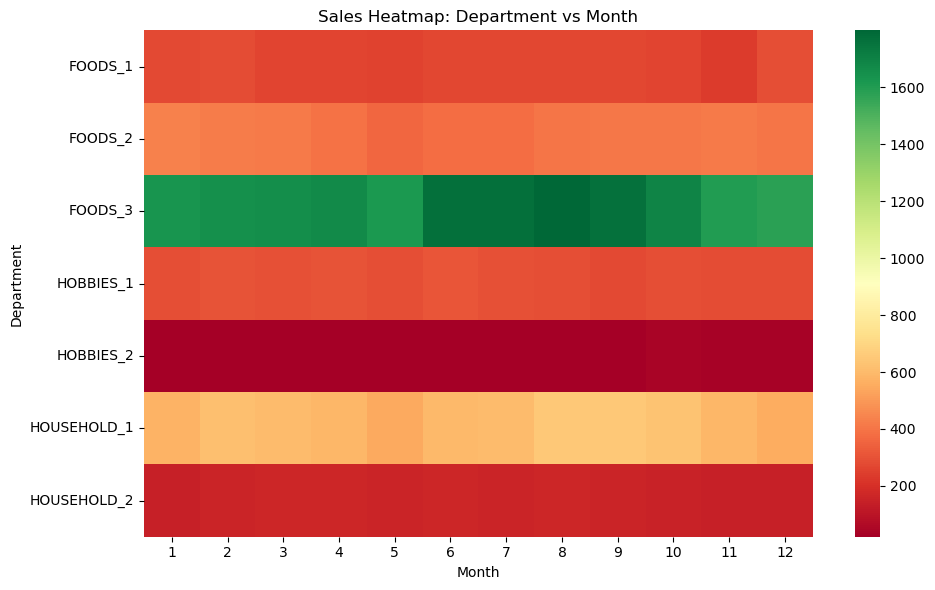

In [13]:
pivot = merged_df.pivot_table(values='sales', index='dept_id', columns='month', aggfunc='mean', observed = True)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, cmap="RdYlGn")

plt.title("Sales Heatmap: Department vs Month", fontsize=12)
plt.xlabel("Month")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [14]:
Dummies = pd.get_dummies(
    Calendar,
    columns=['event_type_1','event_type_2'],
    dtype=int)

Dummies["is_weekend"] = Dummies["weekday"].apply(lambda x: 1 if x in ["Saturday","Sunday"] else 0)

Dummies['wday_sin']   = Dummies["wday"].apply(lambda x: np.sin(2 * np.pi * x / 7))
Dummies['wday_cos']   = Dummies["wday"].apply(lambda x: np.cos(2 * np.pi * x / 7))
Dummies['month_sin']  = Dummies["month"].apply(lambda x: np.sin(2 * np.pi * x / 12))
Dummies['month_cos']  = Dummies["month"].apply(lambda x: np.cos(2 * np.pi * x / 12))

# ── Recency weight — recent days weighted more during training ────────────────
max_d             = Dummies['d'].str[2:].astype(int).max()
Dummies['d_num']  = Dummies['d'].str[2:].astype(int)
half_life         = 180  # weight halves every 180 days
Dummies['sample_weight'] = np.exp(
    -np.log(2) / half_life * (max_d - Dummies['d_num'])
)
Dummies['sample_weight'] = Dummies['sample_weight'] / Dummies['sample_weight'].mean()
Dummies.drop(columns=['d_num'], inplace=True)  # clean up temp column

Dummies.drop(columns=["event_name_1","event_name_2","year","date",
                       "wm_yr_wk","weekday","wday","month"], inplace=True)
Dummies.head(3)

,d,snap_CA,snap_TX,snap_WI,event_type_1_Cultural,event_type_1_National,event_type_1_Religious,event_type_1_Sporting,event_type_2_Cultural,event_type_2_Religious,is_weekend,wday_sin,wday_cos,month_sin,month_cos,sample_weight
0,d_1,0,0,0,0,0,0,0,0,0,1,0.781831,0.623490,0.5,0.866025,0.003872
1,d_2,0,0,0,0,0,0,0,0,0,1,0.974928,-0.222521,0.5,0.866025,0.003887
2,d_3,0,0,0,0,0,0,0,0,0,0,0.433884,-0.900969,0.5,0.866025,0.003902


### Features Extracted from Calendar

**Event Features:**
- `event_type_1` and `event_type_2` converted to binary dummy variables — 
captures whether a day had a sporting, cultural, national or religious event

**Weekend Indicator:**
- `is_weekend` — binary flag (1 = Saturday/Sunday, 0 = weekday) — 
captures the natural sales bump on weekends

**Cyclical Time Features:**
- `wday_sin` & `wday_cos` — captures the cyclical nature of days within a week
- `month_sin` & `month_cos` — captures the cyclical nature of months within a year

> Raw values like `wday` and `month` are dropped in favor of their sine/cosine 
> equivalents — this ensures the model understands that Monday follows Sunday 
> and January follows December, rather than treating time as a straight line.

**Dropped:**
- `event_name_1`, `event_name_2` — too granular
- `year`, `date`, `wm_yr_wk`, `weekday`, `wday`, `month` — redundant 
after feature extraction

*Now Let's explore if we can see some influence of price at the aggreagate dept level* 

In [15]:
temp = viz_train.drop(
    columns=["id", "item_id", "cat_id", "state_id", "wm_yr_wk"]
)
temp = (
    temp
    .groupby(["dept_id", "store_id", "d"], observed=True)
    .agg({
        "sales": "mean",
        "sell_price": "mean"
    })
    .reset_index()
)
df_filtered = temp.loc[
    (temp["dept_id"] == "FOODS_3") &
    (temp["store_id"] == "CA_1")
].copy()
df_filtered["price_bin"] = pd.cut(df_filtered["sell_price"], bins=10)
bin_stats = (
    df_filtered
    .groupby("price_bin", observed=True)["sales"]
    .agg(mean="mean", count="count")
    .reset_index()
)

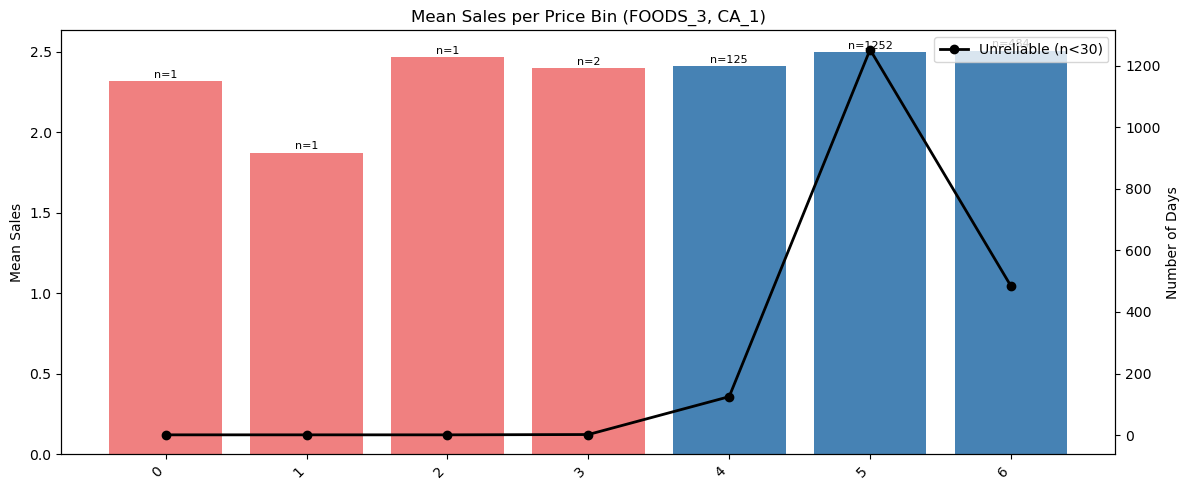

In [16]:
# Define a reliability threshold
threshold = 30  # bins with less than 30 days are unreliable
# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
# Bar colors based on reliability
colors = ['steelblue' if c >= threshold else 'lightcoral' 
          for c in bin_stats['count']]
ax1.bar(range(len(bin_stats)), bin_stats['mean'], color=colors)
ax1.set_xticks(range(len(bin_stats)))
ax1.set_xticklabels(bin_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Mean Sales')
# Overlay count as a line
ax2 = ax1.twinx()
ax2.plot(range(len(bin_stats)), bin_stats['count'], 
         color='black', marker='o', linewidth=2, label='Count')
ax2.set_ylabel('Number of Days')
# Add count labels on top of bars
for i, (mean, count) in enumerate(zip(bin_stats['mean'], bin_stats['count'])):
    ax1.text(i, mean + 0.02, f'n={count}', ha='center', fontsize=8)
plt.legend(['Unreliable (n<30)', 'Reliable (n>=30)'])
plt.title('Mean Sales per Price Bin (FOODS_3, CA_1)')
plt.tight_layout()
plt.show()

### Why `sell_price` is excluded at the Dept+Store Level

When analyzing the relationship between price and sales at the dept+store level, 
the majority of days fell into a very **narrow price range** — most observations 
clustered in just 1-2 bins, leaving the remaining bins with very few data points.

A small number of days in a bin is like surveying **2 people to represent a billion** — 
the average is mathematically correct, but statistically meaningless.

Even among the reliable bins (n≥30), no consistent trend was observed between 
price and sales — confirming that aggregated price is not a useful feature at this level.

> `sell_price` will be used at the **item level** instead, where each item has its 
> own distinct price history and individual price changes are meaningful enough 
> to capture a real relationship with sales.

In [17]:
##Let us create some lag features to our training dataset, these are very important to capture Auto correlation in a time series
g = df_train.groupby(["dept_id", "store_id"],observed = True)["sales"]

##Let’s keep it in multiples of 7 to properly capture weekly seasonality patterns
for lag in [28,35,42,49,364]:
    df_train[f"lag{lag}"] = g.shift(lag)
##Let's create a rolling mean of window 7 to smooth out noise and capture local trend
df_train["roll_mean_7"] = g.shift(28).rolling(7).mean()
df_train["roll_mean_14"] = g.shift(28).rolling(14).mean()
df_train["roll_mean_28"] = g.shift(28).rolling(28).mean()
df_train.dropna(inplace=True)

In [18]:
df_train = df_train.merge(Dummies, on = "d", how = "left")

### Features for Global XGBoost Model

We train a single global model across all 70 time series (7 departments × 10 stores), 
with `dept_id` and `store_id` included as features so the model knows which series it is looking at.

**Lag features** — fold time into columns so XGBoost can see the past:
- `lag_28`, `lag_35`,`lag_42`,`lag_49`,`lag_364` — sales from 4 and 5 weeks ago (`minimum lag_28 ensures no leakage into our 28-day forecast horizon`)
- `roll_mean_7`,`roll_mean_14`,`roll_mean_28` — average sales over 7 and 14 days, shifted 28 days back (captures recent trend without leakage)

**Calendar features** — time patterns and external events:
- `is_weekend`, `wday_sin`, `wday_cos` — day of week effects, encoded cyclically
- `month_sin`, `month_cos` — seasonality within the year
- `event_type_1_*`, `event_type_2_*` — cultural, national, religious and sporting events
- `snap_CA`, `snap_TX`, `snap_WI` — government food stamp purchase days by state

**Series identifiers:**
- `dept_id`, `store_id` — tells the model which of the 70 series it is predicting

In [19]:
## Let us create a validation set respecting the temporal structure and hide it from our model to monitor its performance 
def time_split(df):
    max_d = df['d_num'].max()
    cutoff = max_d - 28
    return df['d_num'] <= cutoff

# Apply split respecting each dept+store combination
train_mask = df_train.groupby(['dept_id','store_id'], group_keys=False, observed= False).apply(time_split, include_groups= False)

df_tr = df_train[train_mask]
df_val = df_train[~train_mask]

print(f"Train: {len(df_tr):,} rows")
print(f"Val:   {len(df_val):,} rows")

Train: 102,597 rows
Val:   1,960 rows


In [20]:
X_train = df_tr.drop(columns=["sales", "d", "d_num", "sample_weight"])
y_train =  df_tr[["sales"]]

X_val = df_val.drop(columns=["sales", "d", "d_num", "sample_weight"])
y_val =  df_val[["sales"]]

model = xgb.XGBRegressor(
    n_estimators=1000,        # Number of trees
    learning_rate=0.05,       # low lr = more robust
    max_depth=8,              # controls complexity
    subsample=0.8,            # row sampling per tree
    colsample_bytree=0.8,     # feature sampling per tree
    min_child_weight=8,      # min samples in a leaf
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,

    # early stopping stops training when val score stops improving
    early_stopping_rounds=50  
)

model.fit(
    X_train, y_train,
    sample_weight     = df_tr['sample_weight'],
    eval_set=[(X_val, y_val)],
    verbose=100,
    )

[0]	validation_0-rmse:630.97747
[100]	validation_0-rmse:88.61822
[196]	validation_0-rmse:88.28988


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


In [21]:
preds = model.predict(X_train)
preds = preds.reshape(-1, 1)

mae  = mean_absolute_error(y_train, preds)
rmse = np.sqrt(np.mean((preds - y_train)**2))
mape = np.mean(np.abs((y_train - preds) / y_train)) * 100
wmape = np.sum(np.abs(y_train.values - preds)) / np.sum(y_train.values) * 100

print(f"MAE on training set:  {mae:.2f}")
print(f"RMSE on training set: {rmse:.2f}")
print(f"MAPE on training set: {mape:.2f}%")
print(f"WMAPE on training set: {wmape:.2f}%")

MAE on training set:  58.68
RMSE on training set: 108.05
MAPE on training set: inf%
WMAPE on training set: 11.39%


In [22]:
preds = model.predict(X_val)
preds = preds.reshape(-1, 1)

mae  = mean_absolute_error(y_val, preds)
rmse = np.sqrt(np.mean((preds - y_val)**2))
mape = np.mean(np.abs((y_val - preds) / y_val)) * 100
wmape = np.sum(np.abs(y_val.values - preds)) / np.sum(y_val.values) * 100

print(f"MAE on Validation Set:  {mae:.2f}")
print(f"RMSE on Validation Set: {rmse:.2f}")
print(f"MAPE on Validation Set: {mape:.2f}%")
print(f"WMAPE on Validation Set: {wmape:.2f}%")  # remove .item() too

MAE on Validation Set:  53.71
RMSE on Validation Set: 87.62
MAPE on Validation Set: 13.30%
WMAPE on Validation Set: 8.89%


### Note on Dataset Usage

All preprocessing steps, feature engineering, and transformations described above were initially developed and validated using the **validation dataset**. This includes reshaping the data, merging calendar and price information, creating lag-based features, and building rolling statistics.

In this section, the **same pipeline is applied to the evaluation dataset for the first time**, ensuring consistency in feature generation and enabling a fair assessment of model performance on truly unseen data. This marks the transition from model development to final evaluation.

In [23]:
### NOW WE USE THE FULL DATASET ALONG WITH THE ACTUAL TEST SET
## Converting the whole in a ML friendly format adding all the features
Test_Set = sales_validation.copy()
Test_Set = Test_Set.melt(
    id_vars=sales_train.columns[0:6],
    var_name="d",
    value_name="sales"
)
##Getting Item Level Prices into Sales dataset
Test_Set = Test_Set.merge(Calendar[["wm_yr_wk","d"]], on = 'd', how = "left" )
Test_Set = Test_Set.merge(selling_prices, on = ["store_id","item_id","wm_yr_wk"], how = "left")
Test_Set = clean_item_prices(Test_Set)

cols = ["dept_id", "store_id", "d"]

for col in cols:
    Test_Set[col] = Test_Set[col].astype("category")

Test_Set = (
    Test_Set
    .drop(columns=["id","item_id","cat_id","state_id","wm_yr_wk"])
    .groupby(["dept_id","store_id","d"], observed=True)
    .agg({"sales": "sum"})
    .reset_index()
)

Test_Set['d_num'] = Test_Set['d'].str.extract(r'(\d+)').astype(int)
Test_Set.sort_values(by=["dept_id", "store_id", "d_num"], inplace=True)
Test_Set.reset_index(drop=True, inplace= True)
Test_Set.head()


g = Test_Set.groupby(["dept_id", "store_id"], observed=True)["sales"]

##Let’s keep it in multiples of 7 to properly capture weekly seasonality patterns (And keep minimum lag 28 to ensure no data leakage)
for lag in [28,35,42,49,364]:
    Test_Set[f"lag{lag}"] = g.shift(lag)
##Let's create a rolling mean of window 7 to smooth out noise and capture local trend
Test_Set["roll_mean_7"] = g.shift(28).rolling(7).mean()
Test_Set["roll_mean_14"] = g.shift(28).rolling(14).mean()
Test_Set.dropna(inplace=True)
Test_Set = Test_Set.merge(Dummies, on = "d", how = "left")

train_mask = Test_Set.groupby(
    ['dept_id','store_id'],
    group_keys=False,
    observed=True
).apply(time_split, include_groups=False)

df_tr = Test_Set[train_mask]
df_test = Test_Set[~train_mask]  ### Actual test set with no dataleakage containing the 28 days sales

In [24]:
## Training the model with the optimal hyperparameter's that we found out earlier ensuring no data leakage

X_train = df_tr.drop(columns=["sales", "d", "d_num", "sample_weight"])
y_train =  df_tr[["sales"]]

X_test = df_test.drop(columns=["sales", "d", "d_num", "sample_weight"])
y_test =  df_test[["sales"]]


## Using the model and hyperparameters chosen based on validation set performance
model_final = xgb.XGBRegressor(
    n_estimators= model.best_iteration,        # Number of trees
    learning_rate=0.05,       # low lr = more robust
    max_depth=8,              # controls complexity
    subsample=0.8,            # row sampling per tree
    colsample_bytree=0.8,     # feature sampling per tree
    min_child_weight=8,      # min samples in a leaf
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

model_final.fit(
    X_train, y_train,
    sample_weight     = df_tr['sample_weight'],
    verbose=100,
    )

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [25]:
## Evaluating the errors on actuals

predictions = model_final.predict(X_test)
predictions = predictions.reshape(-1, 1)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(np.mean((predictions - y_test)**2))

# Most interpretable for sales forecasting
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
wmape = np.sum(np.abs(y_test.values - predictions)) / np.sum(y_test.values) * 100
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"WMAPE: {wmape.item():.2f}%")

MAE:  67.10
RMSE: 112.82
MAPE: 13.21%
WMAPE: 10.68%


In [26]:
Agg_forecast = df_test[["dept_id","store_id","d"]].copy()
Agg_forecast["Sales_Forecast"] = predictions.round()
Agg_forecast.head(3) 

,dept_id,store_id,d,Sales_Forecast
1493,FOODS_1,CA_1,d_1914,302.0
1494,FOODS_1,CA_1,d_1915,273.0
1495,FOODS_1,CA_1,d_1916,274.0


## 📊 Aggregate Forecast

`Agg_forecast` contains the **Department × Store level forecasts** for the **next 28 days**.
By modeling at this aggregated level, we were able to achieve an accuracy of **~91%**, benefiting from more stable demand patterns.

---

## 🔽 Disaggregation to Item Level

The next step is to **distribute these aggregate forecasts down to the Item level**.

The key challenge is to:
- Maintain consistency with aggregate forecasts  
- Preserve demand patterns across items  
- Minimize loss in overall accuracy  

---

## 🎯 Objective

> Convert high-level forecasts into granular item-level predictions  
> while retaining as much of the **~91% accuracy** as possible.

In [27]:
## Let's use the whole sales_validation data and later split the test set before training without any data leakage

Test_Set = sales_validation.copy()
Test_Set = Test_Set.melt(
    id_vars=sales_train.columns[0:6],
    var_name="d",
    value_name="sales"
)
##Getting Item Level Prices into Sales dataset
Test_Set = Test_Set.merge(Calendar[["wm_yr_wk","d"]], on = 'd', how = "left" )
Test_Set = Test_Set.merge(selling_prices, on = ["store_id","item_id","wm_yr_wk"], how = "left")
Test_Set = clean_item_prices(Test_Set)
Test_Set.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wm_yr_wk,sell_price
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,11101,2.00
276022,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_10,0,11102,2.00
30461122,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1000,1,11339,2.24


In [28]:
Item_sales = Test_Set.copy()
#Converting to Categories
for col in ["dept_id", "store_id", "item_id"]:
    Item_sales[col] = Item_sales[col].astype("category")

Item_sales["d_num"] = Item_sales["d"].str[2:].astype("int16")

# sorting 
Item_sales.sort_values(["item_id","store_id","d_num"], inplace=True)    

Item_sales.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wm_yr_wk,sell_price,d_num
1612,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,11101,2.0,1
32102,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,11101,2.0,2
62592,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,11101,2.0,3


In [29]:
per = (Item_sales[Item_sales["sales"]==0].shape[0]/Item_sales.shape[0])*100
print(f"{per:.2f}% of the dataset is filled with 0 sale days")

67.99% of the dataset is filled with 0 sale days


### Addressing Zero Sales — Unconstrained Demand Forecasting

Approximately **68% of item+store days show zero sales**, which can stem from two 
very different scenarios:

- **True zero demand** — the item was available but no customer purchased it that day. 
Getting these right is critical — they are real demand signals the model must learn.

- **Stockout** — the item was simply not on the shelf. These zeros do not reflect 
customer behaviour — they reflect a supply failure. Training a model on these zeros 
teaches it a false pattern: *"customers don't want this item"*, when the reality is 
*"the item wasn't available to buy"*.

To separate these two scenarios, we engineer a `likely_stockout` flag using the 
logic that a stockout is likely when an item records zero sales but at least one 
neighbouring day (before or after) shows non-zero sales — indicating demand exists 
but was interrupted by a supply constraint.

**During training**, this flag is passed as a feature — allowing the model to 
recognise and discount supply-driven zeros rather than learning them as demand behaviour.

**During inference**, the flag is set to 0 for all future days — reflecting the 
assumption that the shelf is stocked. This follows standard supply chain practice 
of forecasting **unconstrained demand** independently of inventory constraints, 
producing a demand signal that replenishment and inventory teams can then act against.

> This distinction between supply zeros and demand zeros is one of the most commonly 
> overlooked sources of forecast bias in retail — and correcting for it is expected 
> to meaningfully reduce error on non-zero days.

In [30]:
Item_sales = Item_sales.sort_values(['item_id', 'store_id', 'd_num'])

Item_sales['prev_day'] = Item_sales['sales'].shift(1)
Item_sales['next_day'] = Item_sales['sales'].shift(-1)

# Zero out cross-series bleed
# where item_id changes, the shift bleeds from previous series
cross_item = Item_sales['item_id'] != Item_sales['item_id'].shift(1)
cross_store = Item_sales['store_id'] != Item_sales['store_id'].shift(1)
Item_sales.loc[cross_item | cross_store, 'prev_day'] = np.nan

cross_item = Item_sales['item_id'] != Item_sales['item_id'].shift(-1)
cross_store = Item_sales['store_id'] != Item_sales['store_id'].shift(-1)
Item_sales.loc[cross_item | cross_store, 'next_day'] = np.nan

## if prev=0 AND next=0, today is NOT a stockout
# if at least one neighbour is non-zero, today IS likely a stockout
is_zero        = Item_sales['sales'] == 0
neighbour_sold = (Item_sales['prev_day'] > 0) | (Item_sales['next_day'] > 0)

Item_sales['likely_stockout'] = (is_zero & neighbour_sold).astype(np.int8)

# Clean up
Item_sales.drop(columns=['prev_day', 'next_day'], inplace=True)

# Check
total_zeros = (Item_sales['sales'] == 0).sum()
flagged     = Item_sales['likely_stockout'].sum()
print(f"Total zeros:          {total_zeros:,}")
print(f"Likely stockouts:     {flagged:,}")
print(f"% of zeros flagged:   {flagged/total_zeros*100:.1f}%")

Total zeros:          39,058,377
Likely stockouts:     10,009,334
% of zeros flagged:   25.6%


In [31]:
Item_sales = Item_sales.sort_values(['item_id','store_id','d_num']).reset_index(drop=True)

Item_sales['lag28_sales'] = Item_sales['sales'].shift(28)
Item_sales['lag35_sales'] = Item_sales['sales'].shift(35)
Item_sales['lag42_sales'] = Item_sales['sales'].shift(42)
Item_sales['lag49_sales'] = Item_sales['sales'].shift(49)
Item_sales['roll7_sales']  = Item_sales['sales'].shift(28).rolling(7).mean()
Item_sales['roll28_sales'] = Item_sales['sales'].shift(28).rolling(28).mean()

Item_sales['roll28_price'] = Item_sales['sell_price'].shift(28).rolling(28).mean()

cross = (Item_sales['item_id'] != Item_sales['item_id'].shift(1)) | \
        (Item_sales['store_id'] != Item_sales['store_id'].shift(1))

for col in ['lag28_sales','lag35_sales','lag42_sales','lag49_sales','roll7_sales','lag364_sales','roll28_sales','roll28_price']:
    Item_sales.loc[cross, col] = np.nan

Item_sales["price_momentum"] =  Item_sales["sell_price"]/ Item_sales["roll28_price"]

## Getting Features from our Calendar Dummies

Item_sales = Item_sales.merge(Dummies, on = "d", how= "left")

### Train / Test Split — Item Level

We split the item level dataset respecting each **item+store combination** independently — 
the last 28 days of each series are held out as the test set, mirroring the exact 
forecast horizon we are targeting.

- `df_tra` — training data, everything up to the last 28 days. **Likely stockout days 
are removed entirely** before training — the model should only learn from days where 
true customer demand was expressed, not days where zero sales reflect a supply failure.
- `df_test` — the final **28 days of actual recorded sales**, never seen by the model 
during training. Stockout days are retained in the test set as they are real observations 
we are evaluated against.

> Removing stockout days from training rather than flagging them as a feature is a 
> deliberate choice — we do not want the model exposed to supply-constrained zeros 
> in any form. This ensures the model learns an unbiased demand signal, producing 
> forecasts that reflect true customer behaviour rather than historical inventory constraints.

In [32]:
# Apply split respecting each Item+store combination
train_mask = (
    Item_sales.groupby(
        ['item_id','store_id'],
        group_keys=False,
        observed=True
    )
    .apply(time_split, include_groups=False)
)

df_tra = Item_sales[train_mask] ## This will be our training set 
df_test = Item_sales[~train_mask] ## This will be the test set of actual sales
df_tra = df_tra[df_tra['likely_stockout'] == 0].copy()

### Feature Engineering: Item Level

At the item level, we retain **event type** rather than event name — with only ~6 
observations per named event per item across 6 years, the signal is too sparse to 
learn reliably. **SNAP indicators** by state are kept as they occur frequently enough 
to carry meaningful signal.

The key addition at this level is **lagged sales features** — without these, 
the model has no memory of each item's historical demand:

- `lag28_sales`, `lag35_sales`, `lag42_sales` — sales from 4, 5 and 6 weeks ago
- `roll7_sales` — average sales over 7 days, shifted 28 days back *(recent trend)*
- `roll28_sales` — average sales over 28 days, shifted 28 days back *(stable baseline)*

We also engineer a **price momentum** feature:

- `price_momentum = sell_price / roll28_price` — captures whether today's price is 
above or below the item's 28 day average price. A value above 1 signals a price 
increase relative to recent history, below 1 signals a markdown or discount. 
This gives the model a relative price signal — not just what the price is, 
but whether it has changed — which is a stronger driver of demand shifts 
than absolute price alone.

The `likely_stockout` flag is used purely as a **data cleaning tool** — rows flagged 
as likely stockouts are removed from the training data entirely, ensuring the model 
only learns from days where true customer demand was expressed. The flag is not 
passed as a feature — the model has no knowledge of stockouts, only clean demand signal.

Together these features allow the model to answer:
> *"Given this item's recent and stable demand history, adjusted for day of week, 
> seasonality, events, SNAP disbursement days, price level, and whether price has 
> recently changed — what is the expected sales for this item tomorrow?"*

### Model: Global XGBoost for Item Level Demand Forecasting

A single **global XGBoost model** is trained across all item+store combinations — 
rather than fitting 30,490 individual models, one model learns demand patterns 
shared across all items, with `item_id` and `store_id` as features to differentiate series.

**Objective:**

We predict **log sales per item** and derive contribution shares post-hoc — allowing 
`log_price` to directly influence predicted demand through the classic **log-log price 
elasticity** relationship, and keeping the target unconstrained and learnable.

The model is intentionally kept **shallow and general** — the goal is not to memorise 
item-level history but to capture the systematic impact of **seasonality, events, SNAP 
days, and price** on demand. A deliberately underfitting model generalises these patterns 
across 30,490 series better than a complex model that overfits to noise in sparse item data.

**Parameter rationale:**
- `max_depth = 4` — shallow trees capture general patterns without memorising noise
- `min_child_weight = 50` — requires sufficient samples per leaf for stable splits
- `tree_method = hist` — histogram-based approximation, significantly faster on datasets of this size

**Disaggregation pipeline:**

> `pred_sales = expm1(model.predict(X)).clip(0)`

> `Contribution = pred_sales / sum(pred_sales within dept+store+day)`

> `Item Forecast = Contribution × Aggregate Dept+Store Forecast`

In [33]:
features = [
    'item_id', 'store_id',
    'sell_price',
    'snap_CA', 'snap_TX', 'snap_WI',
    'event_type_1_Cultural', 'event_type_1_National',
    'event_type_1_Religious', 'event_type_1_Sporting',
    'event_type_2_Cultural', 'event_type_2_Religious',
    'is_weekend', 'wday_sin', 'wday_cos',
    'month_sin', 'month_cos',
    'lag28_sales', 'lag35_sales', 'lag42_sales',
    'roll7_sales', 'roll28_sales','price_momentum','lag49_sales'
]


# Time based split for tuning
cutoff = df_tra['d_num'].max() - 28

df_tune_tr  = df_tra[df_tra['d_num'] <= cutoff]
df_tune_val = df_tra[df_tra['d_num'] > cutoff]

X_tune_tr  = df_tune_tr[features]
y_tune_tr  = df_tune_tr['sales']
X_tune_val = df_tune_val[features]
y_tune_val = df_tune_val['sales']

In [34]:


X_train = df_tra[features]
y_train = df_tra['sales']  


model = xgb.XGBRegressor(
        n_estimators       = 1000,
        learning_rate      = 0.1,
        subsample          = 0.6,
        colsample_bytree   = 0.8,
        random_state       = 42,
        n_jobs             = -1,
        enable_categorical = True,
        tree_method        = 'hist',
        early_stopping_rounds = 30,
        min_child_weight = 10,
        max_depth = 4
    )
model.fit(
        X_tune_tr, y_tune_tr,
        sample_weight     = df_tune_tr['sample_weight'],
        eval_set=[(X_tune_val, y_tune_val)],
        verbose=50
    )

[0]	validation_0-rmse:3.81522
[50]	validation_0-rmse:2.34799
[100]	validation_0-rmse:2.32697
[150]	validation_0-rmse:2.31403
[200]	validation_0-rmse:2.30892
[250]	validation_0-rmse:2.30283
[300]	validation_0-rmse:2.29955
[345]	validation_0-rmse:2.29864


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,30
,enable_categorical,True
,eval_metric,None


In [35]:
df_test = df_test.copy()

predictions = model.predict(df_test[features]).clip(0)

df_test.loc[:, "pred"] = predictions

df_test.loc[:, "Total"] = df_test.groupby(
    ["store_id", "dept_id", "d"], observed=False
)["pred"].transform("sum")

df_test.loc[:, "Contribution"] = (
    df_test["pred"]
    .div(df_test["Total"])
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

### Step 2 — Multiply by Aggregate Forecast

Normalized contributions are mapped to their corresponding **dept+store level aggregate 
forecast**, then multiplied to produce final item level daily sales figures.

**Largest remainder rounding** is applied to preserve integer coherence — rather than 
simple rounding which can cause item forecasts to sum incorrectly, we floor all predictions 
and allocate the remaining units to items with the largest fractional parts. This ensures 
item-level forecasts sum exactly to the aggregate forecast while maintaining discrete units.

In [39]:
df_test = df_test.copy()

# Now rebuild Agg_group AFTER converting
Agg_group = Agg_forecast.groupby(
    ["dept_id","store_id","d"], observed=True
)["Sales_Forecast"].sum()

# Now zip with strings
df_test["map"] = list(zip(
    df_test["dept_id"],
    df_test["store_id"],
    df_test["d"]
))

df_test["Agg_forc"] = df_test["map"].map(Agg_group)

df_test["sales_forecast"] = df_test["Contribution"]*df_test["Agg_forc"]


df_test['sales_forecast'] = pd.to_numeric(df_test['sales_forecast'], errors='coerce')
df_test['sales_forecast_floor'] = df_test['sales_forecast'].apply(np.floor)
df_test['remainder'] = (df_test['sales_forecast'] - df_test['sales_forecast_floor']).astype(float)

def allocate_remainders(group):
    agg_total = pd.to_numeric(group['Agg_forc'].iloc[0])
    floor_total = group['sales_forecast_floor'].sum()
    n_extra = int(round(agg_total - floor_total))
    n_extra = max(0, min(n_extra, len(group)))
    
    if n_extra > 0:
        idx = group['remainder'].astype(float).nlargest(n_extra).index
        group.loc[idx, 'sales_forecast_floor'] += 1
    
    return group

df_test = (
    df_test.groupby(
        ['dept_id','store_id','d'],
        observed=True,
        group_keys=False
    )
    .apply(allocate_remainders, include_groups = True)
    .reset_index()
)

df_test['sales_forecast'] = df_test['sales_forecast_floor'].astype(int)



/var/folders/d1/_3_2b4fd2y5c0sw4bpthdbvr0000gn/T/ipykernel_8030/2478716442.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(allocate_remainders, include_groups = True)


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL MODEL EVALUATION — My Model vs Seasonal Naive Baseline
# ══════════════════════════════════════════════════════════════════════════════

eval_df = df_test.dropna(subset=['sales_forecast', 'lag28_sales']).copy()
eval_df['sales_forecast'] = eval_df['sales_forecast'].clip(0)

actual         = eval_df['sales']
predicted      = eval_df['sales_forecast']
baseline_pred  = eval_df['lag28_sales'].clip(0)

# ── Compute all metrics ───────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error

# RMSE
rmse_model    = np.sqrt(mean_squared_error(actual, predicted))
rmse_baseline = np.sqrt(mean_squared_error(actual, baseline_pred))

# RMSLE
rmsle_model    = np.sqrt(mean_squared_error(np.log1p(actual), np.log1p(predicted)))
rmsle_baseline = np.sqrt(mean_squared_error(np.log1p(actual), np.log1p(baseline_pred)))

# MAE
mae_model    = np.mean(np.abs(actual - predicted))
mae_baseline = np.mean(np.abs(actual - baseline_pred))

# Bias
bias_model    = np.mean(predicted - actual)
bias_baseline = np.mean(baseline_pred - actual)

# Coverage
coverage_model    = predicted.sum() / actual.sum() * 100
coverage_baseline = baseline_pred.sum() / actual.sum() * 100

# ── Print results ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" " * 15 + "FINAL EVALUATION — ITEM LEVEL FORECASTING")
print("=" * 70)
print(f"\nDataset:")
print(f"  Total rows evaluated:      {len(eval_df):,}")
print(f"  Mean daily sales per item: {actual.mean():.4f} units")
print(f"  Zero rate:                 {(actual == 0).mean()*100:.1f}%")
print(f"  Test period:               Last 28 days")

print("\n" + "=" * 70)
print(f"{'Metric':<20} {'Your Model':>15} {'Naive (lag28)':>15} {'Improvement':>15}")
print("-" * 70)
print(f"{'RMSE':<20} {rmse_model:>15.4f} {rmse_baseline:>15.4f} {rmse_baseline - rmse_model:>14.4f}")
print(f"{'RMSLE':<20} {rmsle_model:>15.4f} {rmsle_baseline:>15.4f} {rmsle_baseline - rmsle_model:>14.4f}")
print(f"{'MAE':<20} {mae_model:>15.4f} {mae_baseline:>15.4f} {mae_baseline - mae_model:>14.4f}")
print(f"{'Bias':<20} {bias_model:>15.4f} {bias_baseline:>15.4f} {'':>15}")
print(f"{'Coverage (%)':<20} {coverage_model:>15.2f} {coverage_baseline:>15.2f} {'':>15}")
print("=" * 70)

print(f"\nInterpretation:")
print(f"  RMSE as % of mean:   {rmse_model / actual.mean() * 100:.1f}% (This model)")
print(f"  RMSE improvement:    {(rmse_baseline - rmse_model) / rmse_baseline * 100:.1f}% better than naive")
print(f"  MAE improvement:     {(mae_baseline - mae_model) / mae_baseline * 100:.1f}% better than naive")

# ── By department ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RMSE BY DEPARTMENT")
print("=" * 70)
dept_results = []
for dept in eval_df['dept_id'].unique():
    dept_df = eval_df[eval_df['dept_id'] == dept]
    rmse_m = np.sqrt(mean_squared_error(dept_df['sales'], dept_df['sales_forecast']))
    rmse_b = np.sqrt(mean_squared_error(dept_df['sales'], dept_df['lag28_sales'].clip(0)))
    dept_results.append({
        'dept': dept,
        'model': rmse_m,
        'baseline': rmse_b,
        'improvement': rmse_b - rmse_m
    })

dept_df_results = pd.DataFrame(dept_results).sort_values('improvement', ascending=False)
print(f"{'Department':<15} {'This Model':>12} {'Baseline':>12} {'Improvement':>12}")
print("-" * 70)
for _, row in dept_df_results.iterrows():
    print(f"{row['dept']:<15} {row['model']:>12.4f} {row['baseline']:>12.4f} {row['improvement']:>12.4f}")

print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)
print(f"✓ Hierarchical forecasting approach")
print(f"✓ Aggregate level MAPE:     13% (dept+store level)")
print(f"✓ Item level RMSE:          {rmse_model:.4f}")
print(f"✓ Improvement over naive:   {(rmse_baseline - rmse_model) / rmse_baseline * 100:.1f}%")
print(f"✓ time based features + sample weights + tweedie loss ")
print(f"✓ Stockout-aware training data cleaning")
print("=" * 70 + "\n")


               FINAL EVALUATION — ITEM LEVEL FORECASTING

Dataset:
  Total rows evaluated:      853,720
  Mean daily sales per item: 1.4428 units
  Zero rate:                 54.4%
  Test period:               Last 28 days

Metric                    Your Model   Naive (lag28)     Improvement
----------------------------------------------------------------------
RMSE                          2.2310          2.8292         0.5981
RMSLE                         0.5702          0.6871         0.1169
MAE                           1.0525          1.2840         0.2316
Bias                         -0.0703         -0.0564                
Coverage (%)                   95.13           96.09                

Interpretation:
  RMSE as % of mean:   154.6% (This model)
  RMSE improvement:    21.1% better than naive
  MAE improvement:     18.0% better than naive

RMSE BY DEPARTMENT
Department        This Model     Baseline  Improvement
----------------------------------------------------------------

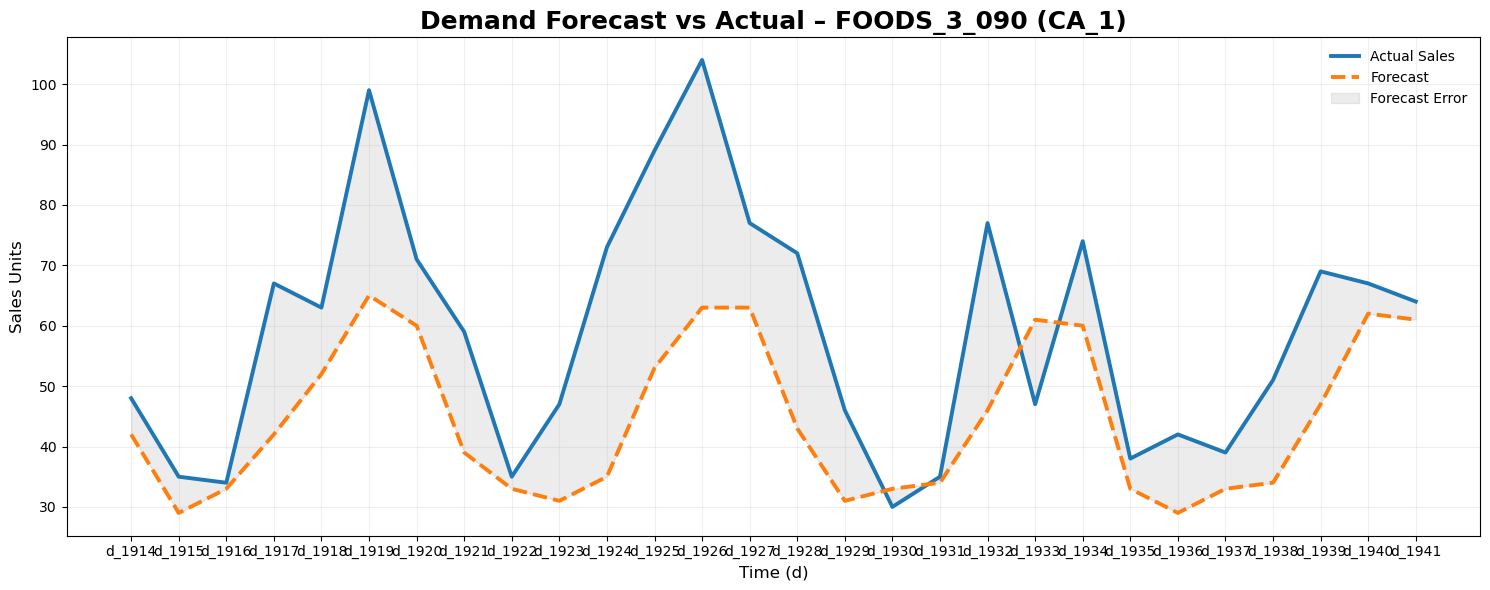

In [67]:
import matplotlib.pyplot as plt

# Filtered dataframe
df_plot = eval_df[
    (eval_df["item_id"] == "FOODS_3_090") &
    (eval_df["store_id"] == "CA_1")
].copy()

# Sort + keep last 15–30 days for clarity
df_plot = df_plot.sort_values("d").tail(30)

plt.figure(figsize=(15,6))

# Actual sales
plt.plot(df_plot["d"], df_plot["sales"],
         label="Actual Sales",
         linewidth=2.8,
         color="#1f77b4")

# Forecast
plt.plot(df_plot["d"], df_plot["sales_forecast"],
         label="Forecast",
         linewidth=2.8,
         linestyle="--",
         color="#ff7f0e")

# Highlight error gap (very LinkedIn-friendly)
plt.fill_between(df_plot["d"],
                 df_plot["sales"],
                 df_plot["sales_forecast"],
                 color="gray",
                 alpha=0.15,
                 label="Forecast Error")

# Styling
plt.title("Demand Forecast vs Actual – FOODS_3_090 (CA_1)",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Time (d)", fontsize=12)
plt.ylabel("Sales Units", fontsize=12)

plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

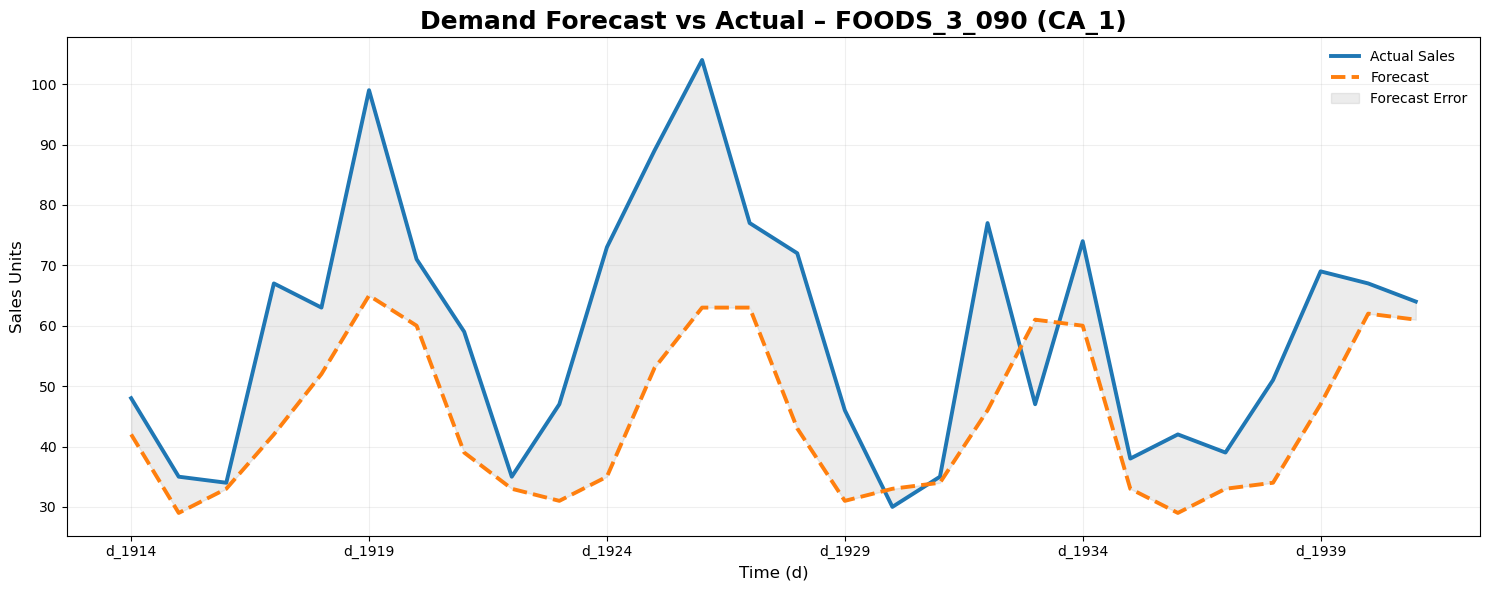

In [68]:
import matplotlib.pyplot as plt

# Filtered dataframe
df_plot = eval_df[
    (eval_df["item_id"] == "FOODS_3_090") &
    (eval_df["store_id"] == "CA_1")
].copy()

# Sort + keep last 30 days
df_plot = df_plot.sort_values("d").tail(30)

plt.figure(figsize=(15,6))

# Actual sales
plt.plot(df_plot["d"], df_plot["sales"],
         label="Actual Sales",
         linewidth=2.8,
         color="#1f77b4")

# Forecast
plt.plot(df_plot["d"], df_plot["sales_forecast"],
         label="Forecast",
         linewidth=2.8,
         linestyle="--",
         color="#ff7f0e")

# Error shading
plt.fill_between(df_plot["d"],
                 df_plot["sales"],
                 df_plot["sales_forecast"],
                 color="gray",
                 alpha=0.15,
                 label="Forecast Error")

# Title + labels
plt.title("Demand Forecast vs Actual – FOODS_3_090 (CA_1)",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Time (d)", fontsize=12)
plt.ylabel("Sales Units", fontsize=12)

# 👇 X-axis every 5 points (KEY FIX)
plt.xticks(df_plot["d"][::5], rotation=0)

plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()